In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import geopandas as gpd
from pyproj import Transformer
from project.data_handling import * 
import pandas as pd

site_dict = {
    'wolverine':['N','B','EC'],
    'kahiltna':['K53','K17b'], 
    'kennicott':['GTL','GTH','KC31'],
    'lemon_creek':['B','C','D'],
    'taku':['NWB1','TKG3'],
    'gulkana':['AU','B','D']
}

### Compare old shading masks (slow, individual point search) to new ones (GPU / vectorized)

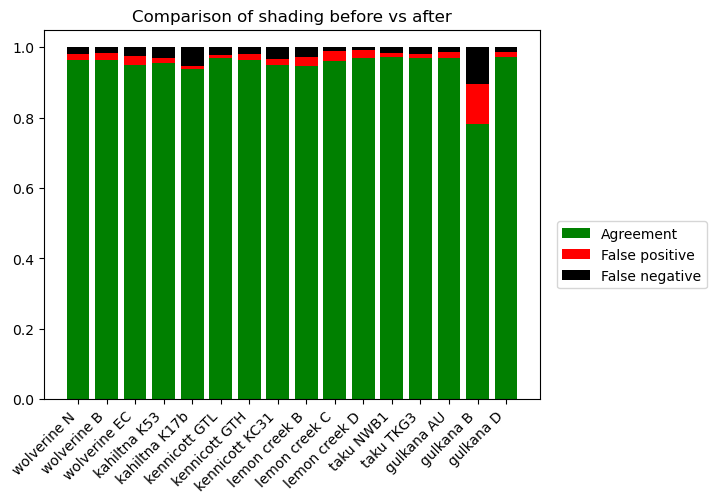

In [2]:
shading_fp = '/home/claire/Local/data/shading/'

# create figure
n_sites = np.sum([len(s) for _, s in site_dict.items()])
fig, ax = plt.subplots()
sites = []
i = 0
for glacier in site_dict:
    glacier_id = translate_rgi[glacier]['6']

    # load the shading file
    file_path = os.path.join(shading_fp, f"{glacier_id}_shadows.nc")
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Could not find shadow file: {file_path}")

    ds = xr.open_dataset(file_path)

    # apply coordinate corrections as needed
    local_times = ds.time.values - np.timedelta64(8, "h")
    ds = ds.assign_coords(time=local_times)
    ds = ds.rio.set_spatial_dims(x_dim='x', y_dim='y')
    ds = ds.rio.write_crs(ds['spatial_ref'].attrs['crs_wkt'])

    # read in the site constants file for this glacier
    df = pd.read_csv(f'data/by_glacier/{glacier}/site_constants.csv', index_col='site')

    for site in site_dict[glacier]:
        # grab lat/lon for this site and convert it to x/y
        point_to_grab = (df.loc[site, 'lat'], df.loc[site, 'lon'])
        transformer = Transformer.from_crs("EPSG:4326", ds.rio.crs, always_xy=True)
        x_pts, y_pts = transformer.transform(point_to_grab[1], point_to_grab[0])

        # get xr DataArrays for the slicing variables
        target_x = xr.DataArray([x_pts], dims='points')
        target_y = xr.DataArray([y_pts], dims='points')

        new_ds = ds.sel(y=target_y, x=target_x, method='nearest').shadow_mask

        # load the old shadow mask
        old_mask = pd.read_csv(f'data/by_glacier/{glacier}/shade/{glacier}{site}_shade.csv', parse_dates=True, index_col=0)
        old_mask['doy'] = old_mask.index.day_of_year
        old_mask['hour'] = old_mask.index.hour

        # load the new shadow mask into a dataframe identical to old_mask
        new_mask = new_ds.to_dataframe(name='shadow_mask').reset_index()
        new_mask['doy'] = pd.DatetimeIndex(new_mask['time']).day_of_year
        new_mask['hour'] = pd.DatetimeIndex(new_mask['time']).hour

        # merge on doy/hour
        comparison = old_mask.merge(new_mask[['doy', 'hour', 'shadow_mask']], 
                                    on=['doy', 'hour'], 
                                    suffixes=('_old', '_new'))

        # calculate error metrics
        old = ~comparison['shaded']
        new = comparison['shadow_mask']
        tp = (old & new).sum()        # both say shadowed
        tn = (~old & ~new).sum()      # both say lit
        fp = (~old & new).sum()       # old says lit, new says shadowed
        fn = (old & ~new).sum()       # old says shadowed, new says lit
        n = len(old)

        # plot stacked bar chart of errors
        ax.bar(i, (tp+tn)/n, color='green')
        ax.bar(i, fp/n, bottom=(tp+tn)/n, color='red')
        ax.bar(i, fn/n, bottom=(tp+tn)/n + fp/n, color='k')
        i+= 1
        sites.append(glacier.replace('_',' ')+' '+site)
ax.bar(0, np.nan, color='green', label='Agreement')
ax.bar(0, np.nan, color='red', label='False positive')
ax.bar(0, np.nan, color='k', label='False negative')
ax.legend(bbox_to_anchor=(1.02, 0.5))
ax.set_xticks(range(n_sites))
ax.set_xticklabels(sites, rotation=45, ha='right')
ax.set_title('Comparison of shading before vs after')
plt.savefig('../shading_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

### Plot the actual shadow mask for a given day of year / hours of day

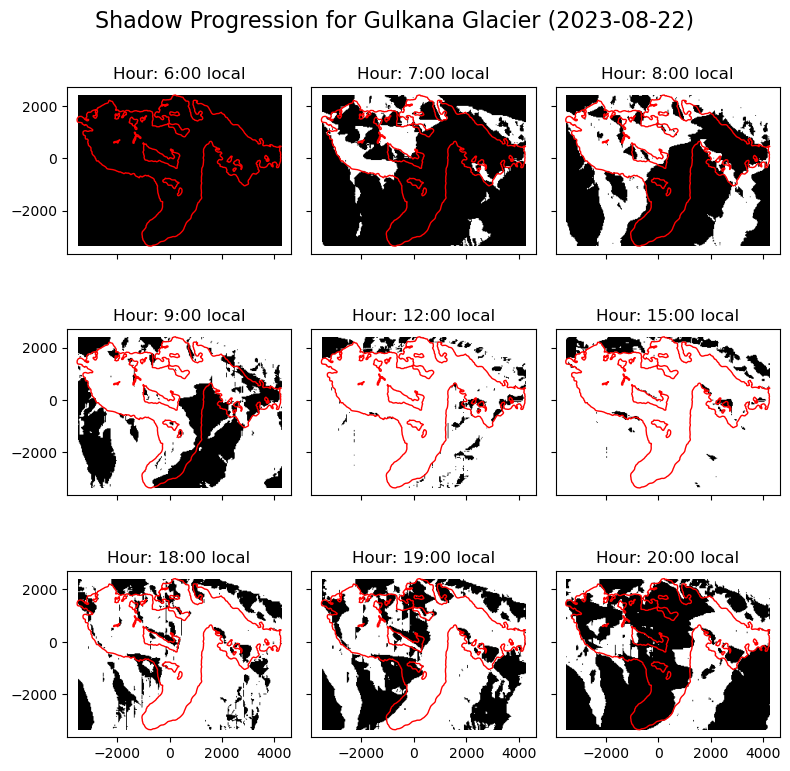

In [3]:
shading_fp = '/home/claire/Local/data/shading/'

glacier = 'gulkana'
glacier_id = translate_rgi[glacier]['6']
date = '2023-08-22'
target_local_hours = [6, 7, 8, 9, 12, 15, 18, 19, 20]

# load the shading file
file_path = os.path.join(shading_fp, f"{glacier_id}_shadows.zarr")
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Could not find shadow file: {file_path}")

ds = xr.open_dataset(file_path)

# apply coordinate corrections as needed
local_times = ds.time.values - np.timedelta64(8, "h")
ds = ds.assign_coords(time=local_times)
ds = ds.rio.set_spatial_dims(x_dim='x', y_dim='y')
ds = ds.rio.write_crs(ds['spatial_ref'].attrs['crs_wkt'])

# select the day specified
date_doy = pd.to_datetime(date).day_of_year
glacier_day = ds.sel(time=ds.time.dt.dayofyear == date_doy)

# initialize plot
fig, axes = plt.subplots(3, 3, figsize=(8, 8), sharex=True, sharey=True)
axes = axes.flatten()

# load the RGI geodataframe for the shapefile
gdf = gpd.read_file('/home/claire/Local/RGI/rgi60/01_rgi60_Alaska/01_rgi60_Alaska.shp')
gdf = gdf.loc[gdf['RGIId'] == 'RGI60-'+glacier_id]
gdf = gdf.to_crs(ds.rio.crs)

# loop through hours
for i, hour in enumerate(target_local_hours):
    ax = axes[i]

    # select the specific hour slice
    hourly_data = glacier_day.sel(time=glacier_day.time.dt.hour == hour)

    # pull out 2D spatial grid
    shadow_grid = hourly_data['shadow_mask'].values.squeeze()

    # Plot the binary shadow map
    # sun = white, shade = black
    im = ax.imshow(
        shadow_grid,
        cmap="gray",
        extent=[
            ds.x.min().item(),
            ds.x.max().item(),
            ds.y.min().item(),
            ds.y.max().item(),
        ],
        origin="upper",
    )

    ax.set_title(f"Hour: {hour}:00 local")

    # plot the shapefile
    gdf.boundary.plot(ax=ax, edgecolor='red', linewidth=1)

fig.suptitle(
    f"Shadow Progression for {glacier.replace('_',' ').capitalize()} Glacier ({date})",
    fontsize=16, y=0.98
)
plt.tight_layout()
plt.savefig('../shadow_map.png', bbox_inches='tight', dpi=300)
plt.show()

ds.close()

### Plot seasonal mass balances

-1.4467704791763763e-12
-7.206300965075795e-08
-3.7931711095601455e-12


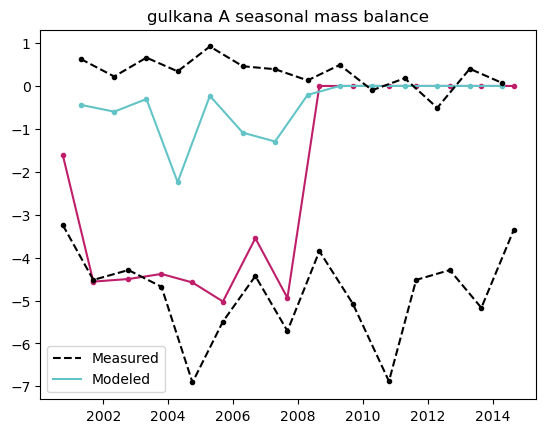

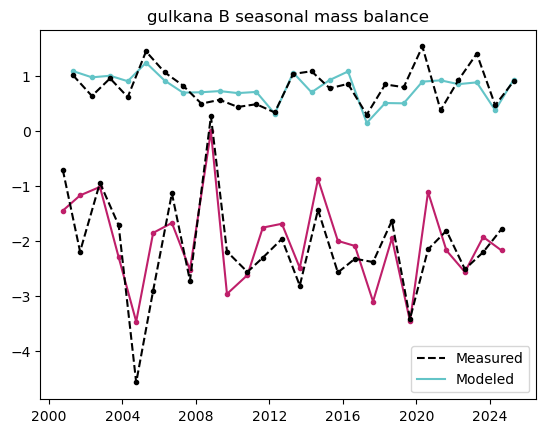

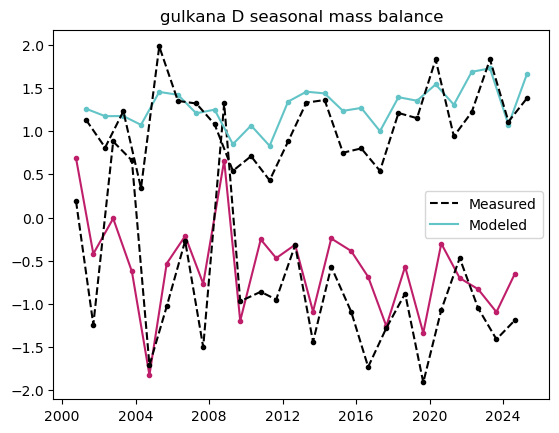

In [ ]:
i = 0
for glacier in ['gulkana']: # site_dict:
    for site in ['A','B','D']: # site_dict[glacier]:
        gn = translate_rgi[glacier]['6']
        mb = MassBalance(glacier, site)
        ds = xr.open_zarr(f'../Output/new_sims_2/{gn}_{i}.zarr')
        mb.get_model_mb(ds)
        mb.plot_mb()
        i += 1

/var/folders/vp/2f8fwwhs579gkbt9hbtf2lz40000gn/T/ipykernel_40333/2111411359.py:54: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  dates = pd.date_range(common[0], common[-1], freq='d') if resample else common
/var/folders/vp/2f8fwwhs579gkbt9hbtf2lz40000gn/T/ipykernel_40333/2111411359.py:54: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  dates = pd.date_range(common[0], common[-1], freq='d') if resample else common
/var/folders/vp/2f8fwwhs579gkbt9hbtf2lz40000gn/T/ipykernel_40333/2111411359.py:54: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  dates = pd.date_range(common[0], common[-1], freq='d') if resample else common
/var/folders/vp/2f8fwwhs579gkbt9hbtf2lz40000gn/T/ipykernel_40333/2111411359.py:54: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  dates = pd.date_range(commo

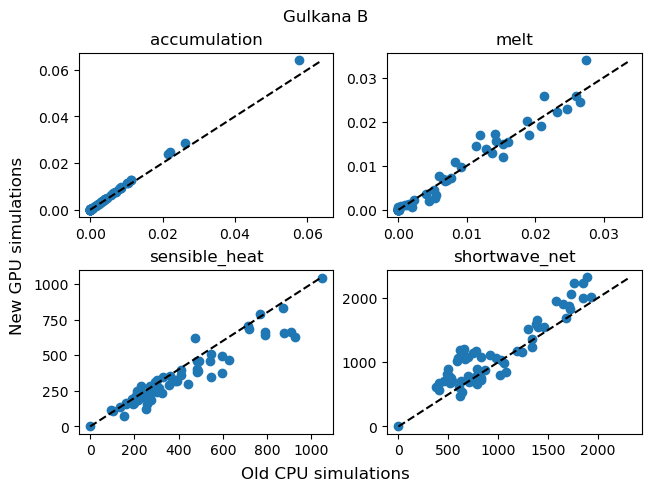

/var/folders/vp/2f8fwwhs579gkbt9hbtf2lz40000gn/T/ipykernel_40333/2111411359.py:54: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  dates = pd.date_range(common[0], common[-1], freq='d') if resample else common
/var/folders/vp/2f8fwwhs579gkbt9hbtf2lz40000gn/T/ipykernel_40333/2111411359.py:54: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  dates = pd.date_range(common[0], common[-1], freq='d') if resample else common
/var/folders/vp/2f8fwwhs579gkbt9hbtf2lz40000gn/T/ipykernel_40333/2111411359.py:54: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  dates = pd.date_range(common[0], common[-1], freq='d') if resample else common
/var/folders/vp/2f8fwwhs579gkbt9hbtf2lz40000gn/T/ipykernel_40333/2111411359.py:54: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  dates = pd.date_range(commo

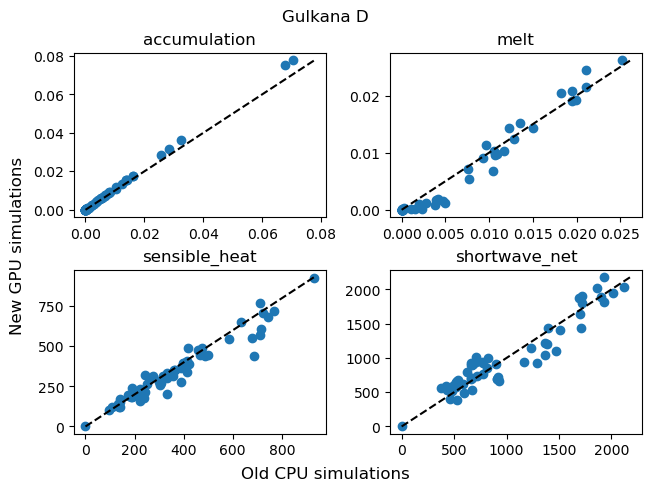

In [96]:
plot_vars = ['accumulation', 'melt', 'sensible_heat', 'shortwave_net']
resample = True
for i, site in enumerate(['B', 'D']):
    ds0 = xr.open_dataset(f'../Output/cpu_sims/gulkana{site}_2026_06_22_base_0.nc')
    # ds0c = xr.open_dataset(f'../Output/cpu_sims/gulkana{site}_2026_06_17_base_1_climate.nc')
    ds1 = xr.open_zarr(f'../Output/new_sims_2/01.00570_{i+1}.zarr')

    # common = pd.to_datetime(np.intersect1d(ds0.time.values, ds1.time.values))
    common = pd.date_range('2024-04-20','2024-06-20',freq='h')
    ds0 = ds0.sel(time=common)
    ds0c = ds0c.sel(time=common + pd.Timedelta(hours=2))
    ds1 = ds1.sel(time=common + pd.Timedelta(hours=2))

    fig, axes = plt.subplots(2, 2)
    axes = axes.flatten()

    for v, ax in zip(plot_vars, axes):
        if v == 'accumulation':
            v0 = 'accum' 
        elif v == 'shortwave_in':
            v0 = 'SWin'
        elif v == 'longwave_in':
            v0 = 'LWin'
        elif v == 'shortwave_net':
            v0 = 'SWnet'
        elif v == 'longwave_net':
            v0 = 'LWnet'
        elif v.endswith('_heat'):
            v0 = v.split('_')[0]
        else:
            v0 = v

        if resample:
            if v in ['melt','accumulation'] or 'shortwave' in v or 'longwave' in v or 'heat' in v:
                vals0 = ds0.isel(layer=0)[v0].resample(time='D').sum().values
                vals1 = ds1.isel(layer=0)[v].resample(time='D').sum().values
            elif v == 'wind':
                vals0 = ds0c[v].resample(time='D').mean().values 
                vals1 = ds1[v].resample(time='D').mean().values
            else:
                vals0 = ds0.isel(layer=0)[v0].resample(time='D').mean().values
                vals1 = ds1.isel(layer=0)[v].resample(time='D').mean().values
        else:
            if v == 'wind':
                vals0 = ds0c[v].values  * 2
            else:
                vals0 = ds0.isel(layer=0)[v0].values 
            vals1 = ds1.isel(layer=0)[v].values

        min_value, max_value = np.min([vals0, vals1]), np.max([vals0, vals1])

        ax.scatter(vals0, vals1)
        ax.plot([min_value, max_value], [min_value, max_value], 'k--')
        dates = pd.date_range(common[0], common[-1], freq='d') if resample else common
        # ax.plot(dates, vals1 - vals0)
        # ax.plot(common, vals1)
    
        # bins = np.linspace(min_value, max_value, 50)
        # ax.hist(vals0, histtype='step', bins=bins)
        # ax.hist(vals1, histtype='step', bins=bins)
        
        ax.set_title(v)
    fig.supxlabel('Old CPU simulations')
    fig.supylabel('New GPU simulations')
    fig.set_constrained_layout(constrained=True)
    fig.suptitle(f'Gulkana {site}')
    plt.show()


In [11]:
ds1

<xarray.Dataset> Size: 6MB
Dimensions:         (time: 1465, layer: 50)
Coordinates:
  * time            (time) datetime64[ns] 12kB 2024-04-20T02:00:00 ... 2024-0...
  * layer           (layer) int64 400B 0 1 2 3 4 5 6 7 ... 43 44 45 46 47 48 49
Data variables: (12/46)
    accumulation    (time) float64 12kB dask.array<chunksize=(167,), meta=np.ndarray>
    airtemp         (time) float64 12kB dask.array<chunksize=(167,), meta=np.ndarray>
    albedo          (time) float64 12kB dask.array<chunksize=(167,), meta=np.ndarray>
    condensation    (time) float64 12kB dask.array<chunksize=(167,), meta=np.ndarray>
    cumrefreeze     (time) float64 12kB dask.array<chunksize=(167,), meta=np.ndarray>
    deposition      (time) float64 12kB dask.array<chunksize=(167,), meta=np.ndarray>
    ...              ...
    sp              (time) float64 12kB dask.array<chunksize=(167,), meta=np.ndarray>
    sublimation     (time) float64 12kB dask.array<chunksize=(167,), meta=np.ndarray>
    surftemp        (time) float64 12kB dask.array<chunksize=(167,), meta=np.ndarray>
    tp              (time) float64 12kB dask.array<chunksize=(167,), meta=np.ndarray>
    wind            (time) float64 12kB dask.array<chunksize=(167,), meta=np.ndarray>
    winddir         (time) float64 12kB dask.array<chunksize=(167,), meta=np.ndarray>
Attributes: (12/30)
    albedo_ice:           0.3315056238104315
    bias_corrected:       temp
    climate_fp:           /Volumes/TOSHIBA EXT/
    config_fn:            sim_redo_config.yaml
    dust_factor:          20
    elevation:            1667.4 m a.s.l.
    ...                   ...
    store_vars:           MB, EB, layers, climate
    time_elapsed:         756.2 s
    use_config:           True
    which_AWS:            none
    which_reanalysis:     MERRA2
    wind_factor:          2.0

In [40]:
# # ds = xr.open_zarr(f'../Output/new_sims_8/01.00570_14.zarr').compute()
# # print(ds.where(ds.sensible_heat < 0, drop=True).sensible_heat)

# ds0 = xr.open_dataset(f'../Output/gulkanaAU_2026_05_12_base_1.nc')
# ds0 = ds0.sel(time=slice('2024-04-20','2024-08-20'))
# plt.plot(ds0.time, ds0.sensible)

# ds = xr.open_zarr(f'../Output/new_sims_9/01.00570_14.zarr').compute()
# # plt.plot(ds.time, ds.airtemp)
# # ds = xr.open_zarr(f'../Output/test_simulation_5/01.00570_2.zarr').compute()
# plt.plot(ds.time, ds.sensible_heat)


airtemp 0.0060570985366438035
longwave_in 0.16714114312229103
sensible_heat 10.302458250583808
latent_heat 3.33754369924197


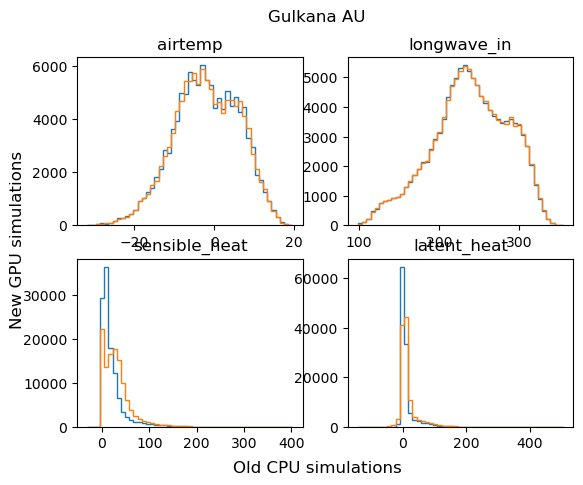

airtemp 0.07018270888820648
longwave_in 0.49399151566151567
sensible_heat 14.651333262753983
latent_heat 4.150289066010867


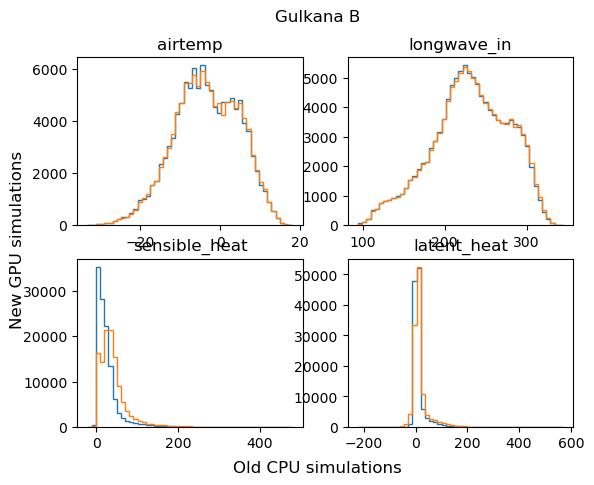

airtemp 0.09170285048976856
longwave_in 0.5947083573871954
sensible_heat 16.44442623200621
latent_heat 5.282556270842455


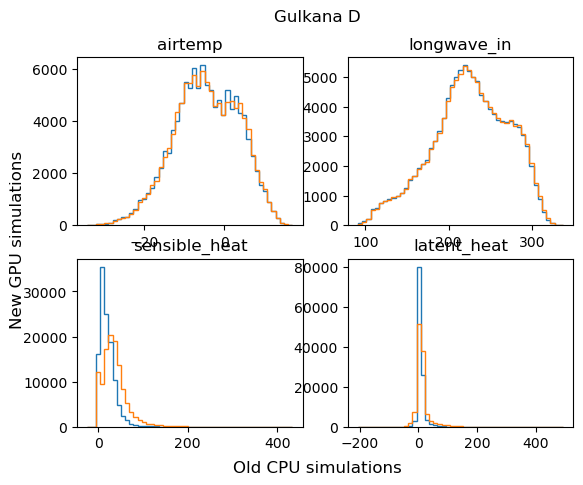

In [ ]:
plot_vars = ['airtemp','longwave_in','sensible_heat','latent_heat',]
resample = False
for i, site in enumerate(['AU','B','D']):
    ds0 = xr.open_dataset(f'../Output/gulkana{site}_2026_05_12_base_1.nc')
    ds1 = xr.open_zarr(f'../Output/new_sims_4/01.00570_{i}.zarr')

    common = pd.to_datetime(np.intersect1d(ds0.time.values, ds1.time.values))
    ds0 = ds0.sel(time=common)
    ds1 = ds1.sel(time=common)

    fig, axes = plt.subplots(2, 2)
    axes = axes.flatten()

    for v, ax in zip(plot_vars, axes):
        if v == 'accumulation':
            v0 = 'accum' 
        elif v == 'shortwave_in':
            v0 = 'SWin'
        elif v == 'longwave_in':
            v0 = 'LWin'
        elif v.endswith('_heat'):
            v0 = v.split('_')[0]
        else:
            v0 = v
            
        if resample:
            if v in ['melt','accumulation', 'shortwave_in', 'longwave_in']:
                vals0 = ds0[v0].resample(time='d').sum().values
                vals1 = ds1[v].resample(time='d').sum().values
            else:
                vals0 = ds0[v0].resample(time='d').mean().values
                vals1 = ds1[v].resample(time='d').mean().values
        else:
            vals0 = ds0[v0].values 
            vals1 = ds1[v].values

        min_value, max_value = np.min([vals0, vals1]), np.max([vals0, vals1])

        # ax.scatter(vals0, vals1)
        # ax.plot([min_value, max_value], [min_value, max_value], 'k--')
        
        print(v, np.mean(vals1 - vals0))

        bins = np.linspace(min_value, max_value, 50)
        ax.hist(vals0, histtype='step', bins=bins)
        ax.hist(vals1, histtype='step', bins=bins)
        
        ax.set_title(v)
    fig.supxlabel('Old CPU simulations')
    fig.supylabel('New GPU simulations')
    fig.suptitle(f'Gulkana {site}')
    plt.show()

In [4]:
# variable = 'wind' 
# glacier = 'gulkana'
# bins = {'temp': np.arange(-40, 40), 'wind': np.arange(0, 30), 'rh': np.arange(0, 100, 5), 'SWin': np.arange(0, 3e6, 1e4)}

# for variable in ['temp','wind','SWin','rh']:
#     for glacier in ['gulkana','kahiltna','wolverine','lemon_creek']:
#         vx = variable + '_0' if variable == 'temp' else variable
#         if not os.path.exists(f'data/bias_adjustment/quantile_mapping_{glacier}_{vx}.csv'):
#             continue
#         before = pd.read_csv(f'data/bias_adjustment/quantile_mapping_{glacier}_{vx}.csv')
#         before_aws = before['mapping']
#         before_merra = before['sorted']

#         after = xr.open_dataset('data/quantile_cdfs.nc', group=variable)
#         stations = after.station.values 
#         station = [f for f in stations if f.startswith(glacier)]
#         if len(station) < 1:
#             continue
#         after_aws = after.sel(station=station[0]).aws_cdf.values 
#         after_merra = after.sel(station=station[0]).merra_cdf.values 

#         fig, axes = plt.subplots(2)
#         axes[0].hist(before_aws, bins = bins[variable], histtype='step', density=True, label='Before')
#         axes[0].hist(after_aws, bins=bins[variable], histtype='step', density=True, label='After')
#         axes[0].legend()
#         axes[0].set_title('AWS')

#         axes[1].hist(before_merra, bins = bins[variable], histtype='step', density=True, label='Before')
#         axes[1].hist(after_merra, bins=bins[variable], histtype='step', density=True, label='After')
#         axes[1].set_title('MERRA-2')
#         fig.suptitle(f'{glacier.capitalize()} {variable} bias correction before / after')
#         fig.set_constrained_layout(constrained=True)
#         plt.show()